# Neural Gas Algorithm
### A flexible alternative to Self-Organizing Maps

**Key idea:** Instead of constraining neurons to a fixed grid like SOM,
Neural Gas lets neurons float freely in data space.
Neurons arrange themselves purely by data density — no grid, no topology constraints.

**When to use Neural Gas over SOM:**
- Data has irregular cluster shapes
- You don't need a 2D map visualization
- You want neurons to concentrate where data is densest

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, make_moons, make_blobs
from sklearn.metrics import silhouette_score
from kohonen.som import SOM
from kohonen.neural_gas import NeuralGas

## Part 1 — Neural Gas on Iris
Same dataset as the SOM basics notebook — lets us compare directly.

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
class_names = [iris.target_names[i] for i in y]

ng = NeuralGas(n_neurons=20, learning_rate_i=0.5,
               learning_rate_f=0.01, neighborhood_i=10,
               neighborhood_f=0.1)
ng.fit(X, epochs=2000)

Training complete. Quantization Error: 0.0989


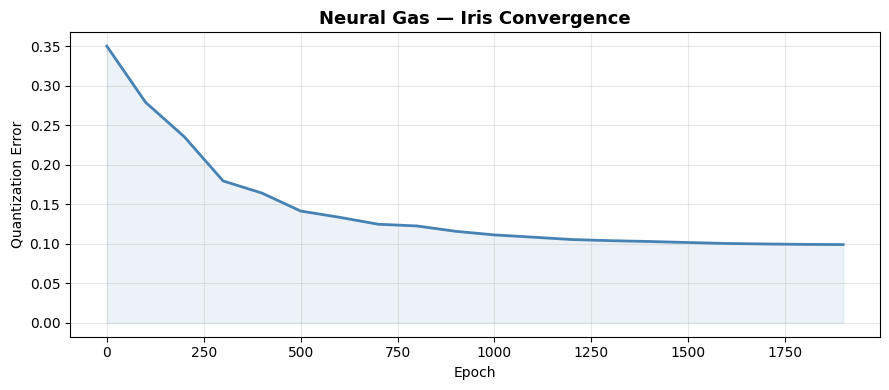

In [3]:
ng.plot_convergence(title="Neural Gas — Iris Convergence")

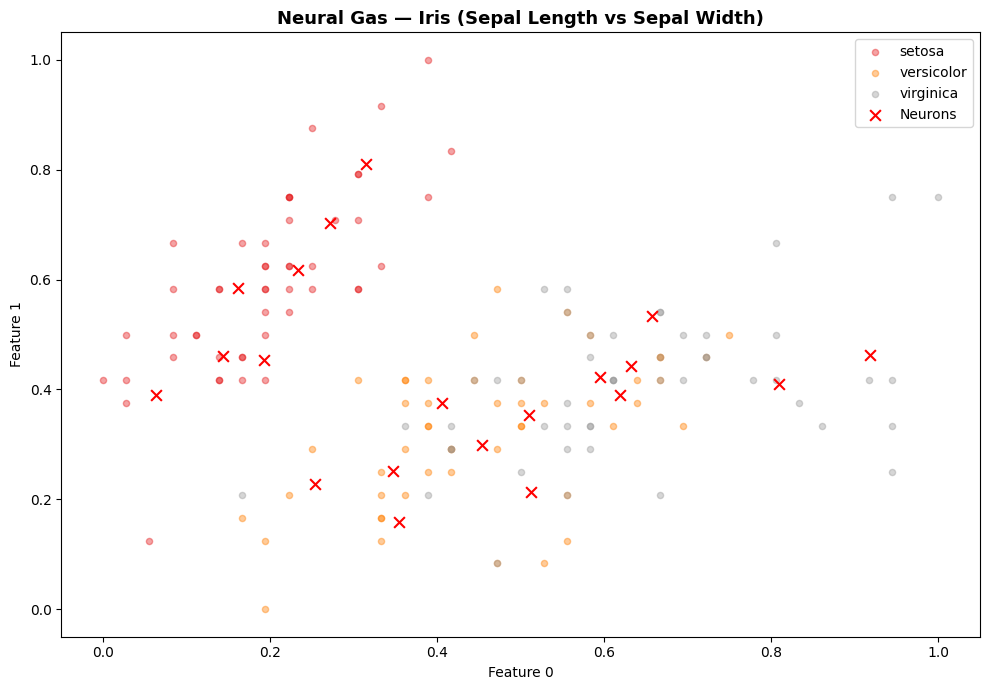

In [4]:
ng.plot_neurons(X, labels=class_names, feature_idx=(0, 1),
                title="Neural Gas — Iris (Sepal Length vs Sepal Width)")

## Part 2 — Where Neural Gas beats SOM
SOM struggles with non-rectangular cluster shapes because the grid
forces a rigid topology. Neural Gas has no such constraint.

Let's demonstrate on `make_moons` — two interleaving half-circles
that no grid can represent cleanly.

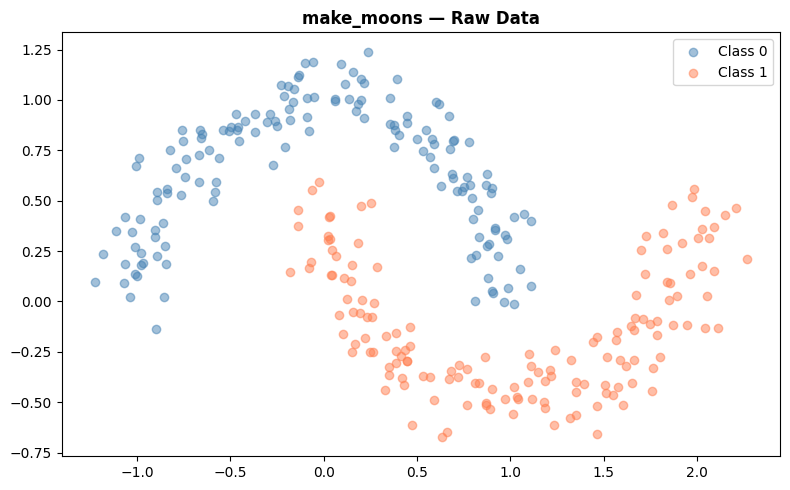

In [5]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=300, noise=0.1, random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_moons[y_moons==0, 0], X_moons[y_moons==0, 1],
           alpha=0.5, label='Class 0', color='steelblue')
ax.scatter(X_moons[y_moons==1, 0], X_moons[y_moons==1, 1],
           alpha=0.5, label='Class 1', color='coral')
ax.set_title("make_moons — Raw Data", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# Neural Gas
ng_moons = NeuralGas(n_neurons=30, learning_rate_i=0.5,
                     learning_rate_f=0.01, neighborhood_i=10,
                     neighborhood_f=0.1, random_seed=42)
ng_moons.fit(X_moons, epochs=3000, verbose=True)

# SOM
som_moons = SOM(grid_x=6, grid_y=5, learning_rate=0.5, sigma=1.5)
som_moons.fit(X_moons, epochs=3000, verbose=True)

Training complete. Quantization Error: 0.0422
Training SOM (6x5) for 3000 epochs...
Done. Quantization Error: 0.0486 | Topographic Error: 0.0000


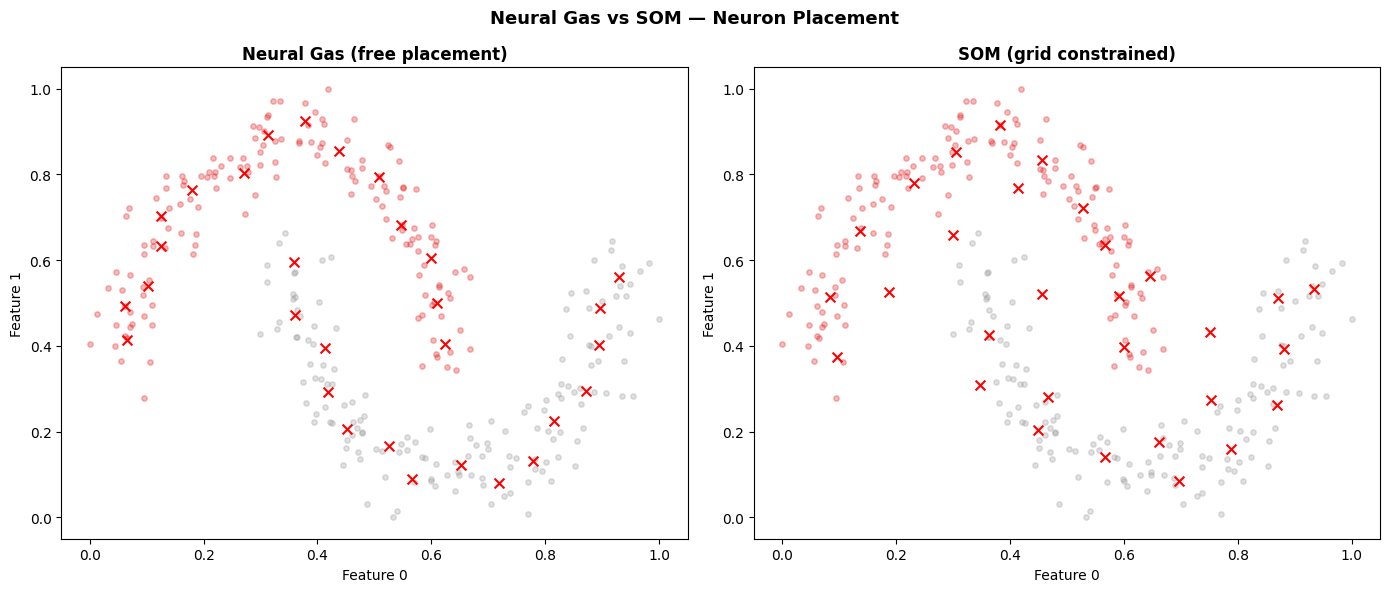

In [7]:
ng_moons.compare_with_som(X_moons, som_moons,
                           labels=y_moons, feature_idx=(0, 1))

### What you should see
- **Neural Gas**: neurons hug the moon shapes — they go where the data is
- **SOM**: neurons form a grid pattern — can't bend to follow the curves

This is the core tradeoff:
| | Neural Gas | SOM |
|---|---|---|
| Neuron placement | Follows data density | Constrained to grid |
| Visualization | Hard (no 2D map) | Easy (U-Matrix, hit map) |
| Irregular clusters | Handles well | Struggles |
| Interpretability | Lower | Higher |

## Part 3 — Quantitative Comparison on Iris
Which algorithm clusters Iris better?
We use Silhouette Score — measures how well separated clusters are.
Score range: -1 (bad) to +1 (perfect).

In [8]:
# Neural Gas clustering
ng_iris = NeuralGas(n_neurons=15, learning_rate_i=0.5,
                    learning_rate_f=0.01, random_seed=42)
ng_iris.fit(X, epochs=2000, verbose=False)
ng_labels = ng_iris.predict(X)

# SOM clustering
som_iris = SOM(grid_x=8, grid_y=8, learning_rate=0.5, sigma=1.5)
som_iris.fit(X, epochs=1000, verbose=False)
som_labels = som_iris.predict(X)

# Silhouette scores
ng_sil  = silhouette_score(X, ng_labels)
som_sil = silhouette_score(X, som_labels)

print(f"Neural Gas  — Silhouette Score : {ng_sil:.4f}")
print(f"SOM         — Silhouette Score : {som_sil:.4f}")
print(f"Neural Gas  — Quantization Error : {ng_iris.quantization_error():.4f}")
print(f"SOM         — Quantization Error : {som_iris.quantization_error():.4f}")

Neural Gas  — Silhouette Score : 0.1680
SOM         — Silhouette Score : 0.1144
Neural Gas  — Quantization Error : 0.1130
SOM         — Quantization Error : 0.0683


## Part 4 — Tuning Neural Gas
Two key parameters control how neurons spread:

- **n_neurons**: more neurons = finer granularity, slower training
- **neighborhood_i**: high initial neighborhood = neurons spread out first, then specialize

Let's see how n_neurons affects quantization error.

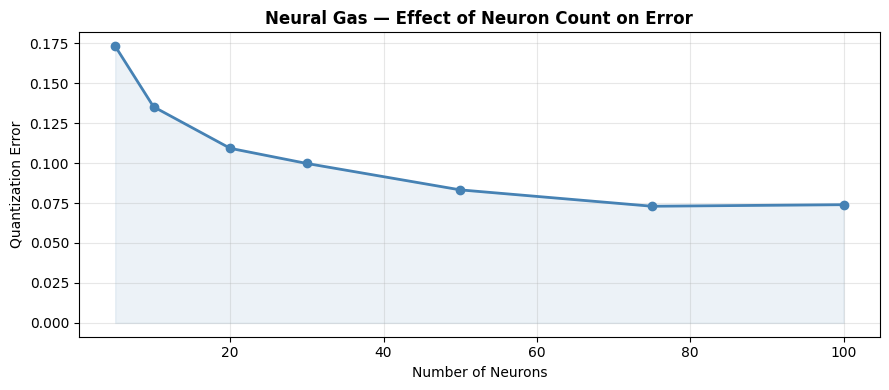

More neurons = lower error, but diminishing returns after ~30 for Iris


In [9]:
neuron_counts = [5, 10, 20, 30, 50, 75, 100]
qe_scores = []

for n in neuron_counts:
    ng_temp = NeuralGas(n_neurons=n, random_seed=42)
    ng_temp.fit(X, epochs=1000, verbose=False)
    qe_scores.append(ng_temp.quantization_error())

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(neuron_counts, qe_scores, 'o-', color='steelblue', linewidth=2)
ax.fill_between(neuron_counts, qe_scores, alpha=0.1, color='steelblue')
ax.set_xlabel("Number of Neurons")
ax.set_ylabel("Quantization Error")
ax.set_title("Neural Gas — Effect of Neuron Count on Error",
             fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("More neurons = lower error, but diminishing returns after ~30 for Iris")

## Summary

| Aspect | Neural Gas | SOM |
|---|---|---|
| Grid required | No | Yes |
| Best for | Density estimation, irregular clusters | Visualization, topology mapping |
| Output | Cluster labels | 2D map + labels |
| Interpretability | Medium | High |
| Handles curved clusters | Yes | Limited |

**Rule of thumb**: Use SOM when you need a visual map of your data.
Use Neural Gas when you care more about clustering quality than visualization.